In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import os
import sys
import gc
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
import torch

main_folder = "../.."
sys.path.insert(0, os.path.join(main_folder))

from src.config import EXP_CONFIGS
from src.utils import build_binary_aux_cfg
from src.inference_feedback import (
    extract_aux_oof_to_csv,
    sweep_thresholds, uncertainty_band, assign_reliability,
    load_model,
    run_batch,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

TARGET     = "Pawpularity"
IMG_FOLDER = os.path.join(main_folder, "data", "train")
CSV_PATH   = os.path.join(main_folder, "data", "train.csv")
df         = pd.read_csv(CSV_PATH)
AUX_TASKS  = ["Eyes", "Face", "Occlusion", "Blur"]
SWIN_GRID  = (12, 12)

# exp19: standard BCE aux heads
out_dir_exp19 = os.path.join(main_folder, "outputs", "extra",
                             "exp19_swin_384_strong_MSELoss_Multiple_Aux_StrongHead")

cfg_exp19 = EXP_CONFIGS["exp15_aux_brisque"].copy()
cfg_exp19["img_size"] = 384
cfg_exp19["name"] = "exp19_swin_384_strong_MSELoss_Multiple_Aux_StrongHead"
cfg_exp19["loss"] = "mse"
cfg_exp19["head_type"] = "mlp"
cfg_exp19["aux_tasks"] = []
cfg_exp19["binary_aux_tasks"] = ["Eyes", "Face", "Occlusion", "Blur"]
cfg_exp19["aux_loss_weights"] = {"Face": 0.1, "Eyes": 0.1, "Occlusion": 0.1, "Blur": 0.1}
cfg_exp19["use_saliency"] = False

ACTIVE_CFG = cfg_exp19
ACTIVE_DIR = out_dir_exp19


Device: cuda


In [35]:

# To create the aux head with the probabilities for each record and each aux head and save it to a CSV file
aux_df = extract_aux_oof_to_csv(
    out_dir=ACTIVE_DIR,
    df=df,
    img_folder=IMG_FOLDER,
    cfg=ACTIVE_CFG,
    device=device,
)

Loading existing: ../../outputs/extra/exp19_swin_384_strong_MSELoss_Multiple_Aux_StrongHead/oof_detail_aux.csv


### Label Thresholds based on Maximum F1 value
Compute per-label thresholds based on maximum F1 and near that F1 max value, 90% is taken as uncertain. This is because the F1 curve around its peak is
often flat. multiple nearby thresholds perform almost equally well . so
 committing to one exact threshold overstates the model's decision.
 Any probability falling inside [uncertain_low, uncertain_high] (the region
 where F1 >= 90% of its peak) is treated as uncertain


In [36]:
#  compute per-label thresholds based on maximum F1 

LABEL_POLICY = {}

print("\n" + "=" * 70)
print(f"{'Label':<11} {'Threshold':>10} {'PeakF1':>8} {'Prec':>7} {'Rec':>7} {'Uncertain Threshold Region':>18}")
print("-" * 70)

for task in AUX_TASKS:
    # True labels and predicted probabilities from aux CSV
    y_true = aux_df[f"{task}_true"].values
    y_prob = aux_df[f"{task}_prob"].values

    thresholds, f1s, precs, recs, best_idx = sweep_thresholds(y_true, y_prob)
    thr       = float(thresholds[best_idx])
    peak_f1   = float(f1s[best_idx])
    peak_prec = float(precs[best_idx])
    peak_rec  = float(recs[best_idx])
    # Uncertainty band where F1 is close to the peak
    unc_lo, unc_hi = uncertainty_band(thresholds, f1s, best_idx)

    # Store  
    LABEL_POLICY[task] = {
        "threshold": thr,
        "uncertain_low": unc_lo,
        "uncertain_high": unc_hi,
        "peak_f1": peak_f1,
        "peak_prec": peak_prec,
        "peak_rec": peak_rec,
    }
    print(f"{task:<11} {thr:>10.2f} {peak_f1:>8.4f} {peak_prec:>7.4f} {peak_rec:>7.4f} [{unc_lo:.2f}, {unc_hi:.2f}]")
print("=" * 90)


Label        Threshold   PeakF1    Prec     Rec Uncertain Threshold Region
----------------------------------------------------------------------
Eyes              0.69   0.8873  0.8109  0.9795 [0.01, 0.77]
Face              0.82   0.9542  0.9194  0.9917 [0.01, 0.89]
Occlusion         0.21   0.4450  0.3904  0.5173 [0.16, 0.25]
Blur              0.07   0.1779  0.1138  0.4069 [0.06, 0.07]


### Uncertainity And Reliability Table

In [37]:
# reliability and display policy table 
# if the aux head F1 is  >= 0.75: high reliable, 0.60 to 0.75 Medium Reliable, <0.60 unreliable
# these values are taken statically because The cutoff 0.60 is near the average of PeakF1 of all Four aux variable and 0.75 accordingly can be considered high reliable
rows = []
for task in AUX_TASKS:
    p = LABEL_POLICY[task]
    reliability, display = assign_reliability(p["peak_f1"])
    LABEL_POLICY[task]["display"] = display

    rows.append({
        "Auxiliary Label":    task,
        "F1":                 round(p["peak_f1"],   4),
        "Precision":          round(p["peak_prec"], 4),
        "Recall":             round(p["peak_rec"],  4),
        "Decision Threshold": round(p["threshold"], 2),
        "Uncertain Threshold":     f"[{p['uncertain_low']:.2f}, {p['uncertain_high']:.2f}]",
        "Reliability":        reliability,
        "User Display Policy": {
            "show":          "Display with confidence-aware wording",
            "supplementary": "Show as supplementary note only",
            "exclude":       "Excluded from user output",
        }[display],
    })

reliability_df = pd.DataFrame(rows)
reliability_df.head()

,Auxiliary Label,F1,Precision,Recall,Decision Threshold,Uncertain Threshold,Reliability,User Display Policy
0,Eyes,0.8873,0.8109,0.9795,0.69,"[0.01, 0.77]",High,Display with confidence-aware wording
1,Face,0.9542,0.9194,0.9917,0.82,"[0.01, 0.89]",High,Display with confidence-aware wording
2,Occlusion,0.4450,0.3904,0.5173,0.21,"[0.16, 0.25]",Low,Excluded from user output
3,Blur,0.1779,0.1138,0.4069,0.07,"[0.06, 0.07]",Low,Excluded from user output


In [38]:
# load all fold checkpoints
allFolds_models = []
for fold in range(1, ACTIVE_CFG["n_splits"] + 1):
    try:
        allFolds_models.append(load_model(fold, ACTIVE_CFG, ACTIVE_DIR, device))
        print(f"fold {fold} loaded")
    except FileNotFoundError as e:
        print("skipped:", e)

fold 1 loaded
fold 2 loaded
fold 3 loaded
fold 4 loaded
fold 5 loaded


In [39]:
# Ground-truth lookup dicts — used in evaluation output
true_paw_dict = dict(zip(df["Id"], df["Pawpularity"]))  # map each image id to pawpularity score, e.g. {"abcd1234": 75, ...}
true_aux_dict = {
    row["Id"]: {
        "Eyes": row["Eyes"],
        "Face": row["Face"],
        "Occlusion": row["Occlusion"],
        "Blur": row["Blur"],
    }
    for _, row in df.iterrows()
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
_, val_idx = list(kf.split(df))[0]  # fold1
val_df = df.iloc[val_idx].reset_index(drop=True)

# Pool of  images (high/low/median mix) Pawpularity
high_ids = val_df.nlargest(2, "Pawpularity")["Id"].tolist()
low_ids  = val_df.nsmallest(2, "Pawpularity")["Id"].tolist()
median   = val_df["Pawpularity"].median()
mid_ids  = val_df.assign(_d=(val_df["Pawpularity"] - median).abs()).nsmallest(2, "_d")["Id"].tolist()
pool_ids = list(dict.fromkeys(high_ids + low_ids + mid_ids))  
labels = {}
for img_id in high_ids:
    labels[img_id] = "High Pawpularity"
for img_id in low_ids:
    labels[img_id] = "Low Pawpularity"
for img_id in mid_ids:
    labels[img_id] = "Mid Pawpularity"


### 1) Single Image
As from the above reliability table, Blur and Occlusion F1 is below the cut off , so they are not included in the user feedback 

Overall Pipeline outputs 1–6 produced for single image:
- 1 — input image
- 2 — predicted Pawpularity score
- 3 — auxiliary semantic predictions and probabilities
- 4 — confidence-aware feedback
- 5 — Grad-CAM overlay
- 6 — separate user-facing and evaluation outputs

In [40]:
random_id = val_df.sample(1, random_state=42)["Id"].tolist()
print("random singleimage id", random_id)

random singleimage id ['4b792ec239070d4135b7a1bdcdcfea9f']


********************************************************************************

ImgId: 4b792


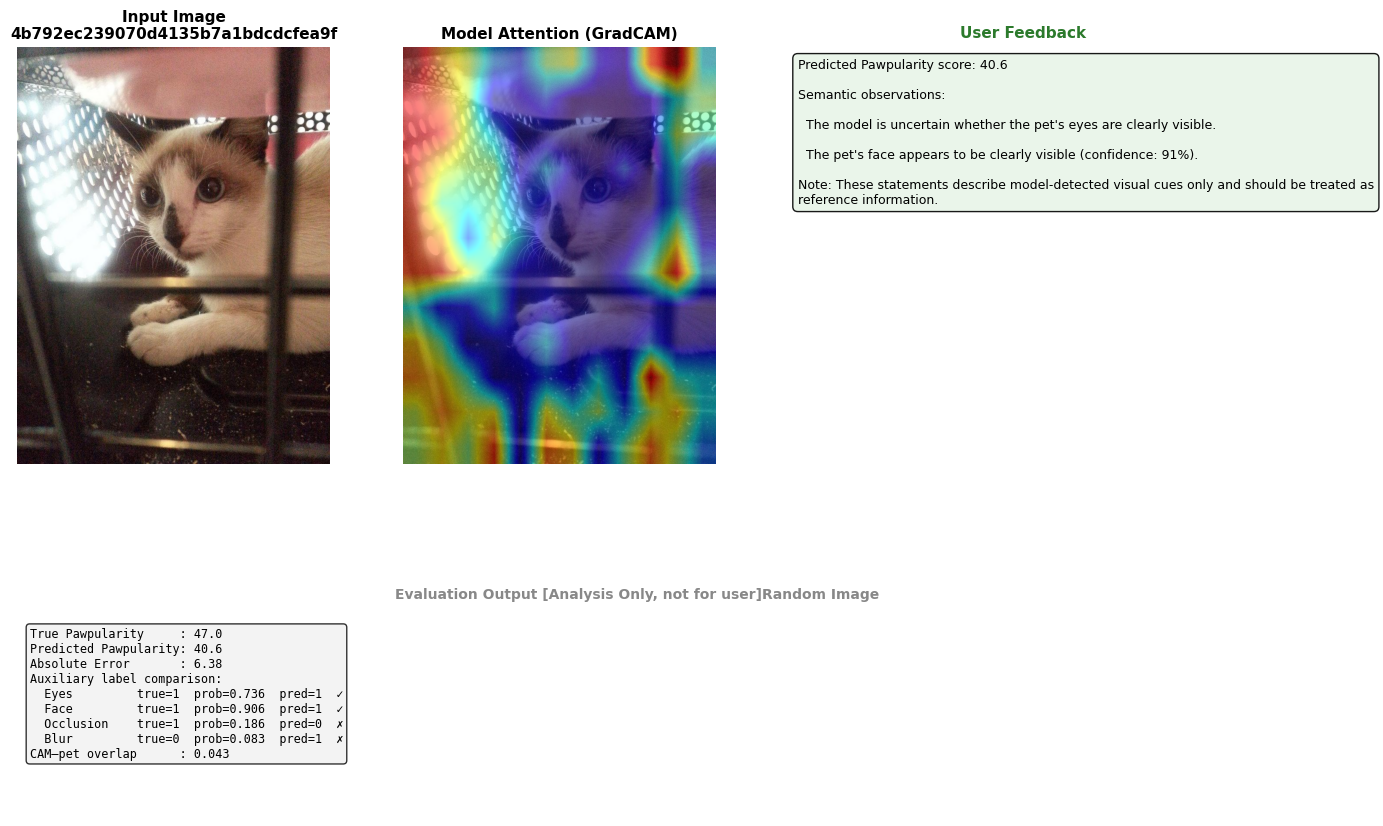

,Id,true_paw,pred_paw,cam_pet_overlap,eyes_true,eyes_prob,eyes_pred,face_true,face_prob,face_pred,occlusion_true,occlusion_prob,occlusion_pred,blur_true,blur_prob,blur_pred
0,4b792ec239070d4135b7a1bdcdcfea9f,47,40.62,0.043,1,0.736,1,1,0.906,1,1,0.186,0,0,0.083,1


In [ ]:
# Pipeline outputs 1–6 produced for single image:
#   1 — input image
#   2 — predicted Pawpularity score
#   3 — auxiliary semantic predictions and probabilities
#   4 — confidence-aware feedback
#   5 — Grad-CAM overlay
#   6 — separate user-facing and evaluation outputs
SAVE_DIR_DEMO = os.path.join(main_folder, "outputs", "extra", "feedback_prototype_demo")
demo_df = run_batch(
    image_ids=random_id,
    img_folder=IMG_FOLDER,
    cfg=ACTIVE_CFG,
    allFolds_models=allFolds_models,
    label_policy=LABEL_POLICY,
    aux_tasks=AUX_TASKS,
    swin_grid=SWIN_GRID,
    device=device,
    true_paw_dict=true_paw_dict,
    true_aux_dict=true_aux_dict,
    save_dir=SAVE_DIR_DEMO,
    use_yolo=True,
    labels={random_id[0]: "Random Image"},
)
demo_df

### 2) High, Med and Low Pawpularity representative images

********************************************************************************

ImgId: 00768


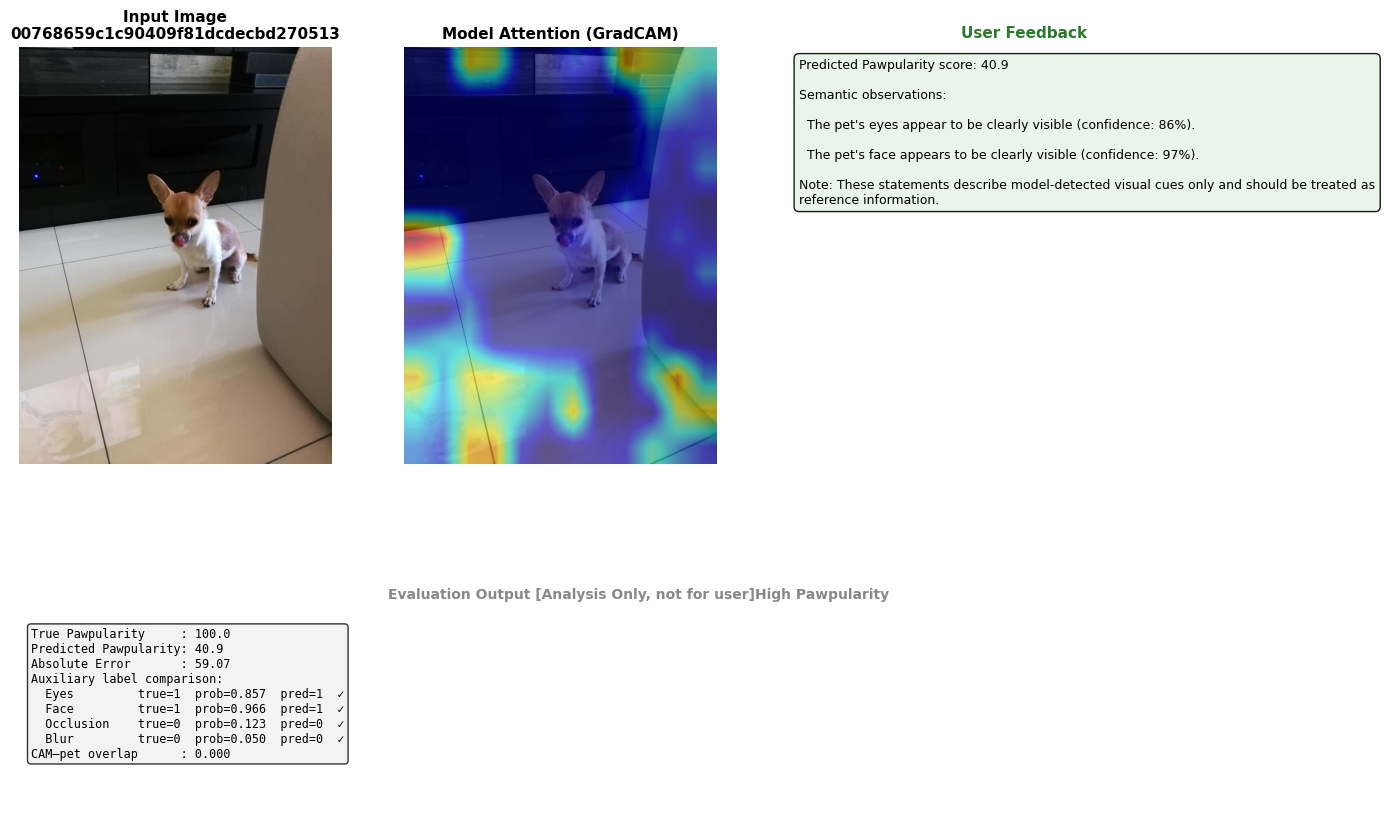

********************************************************************************

ImgId: 013f8


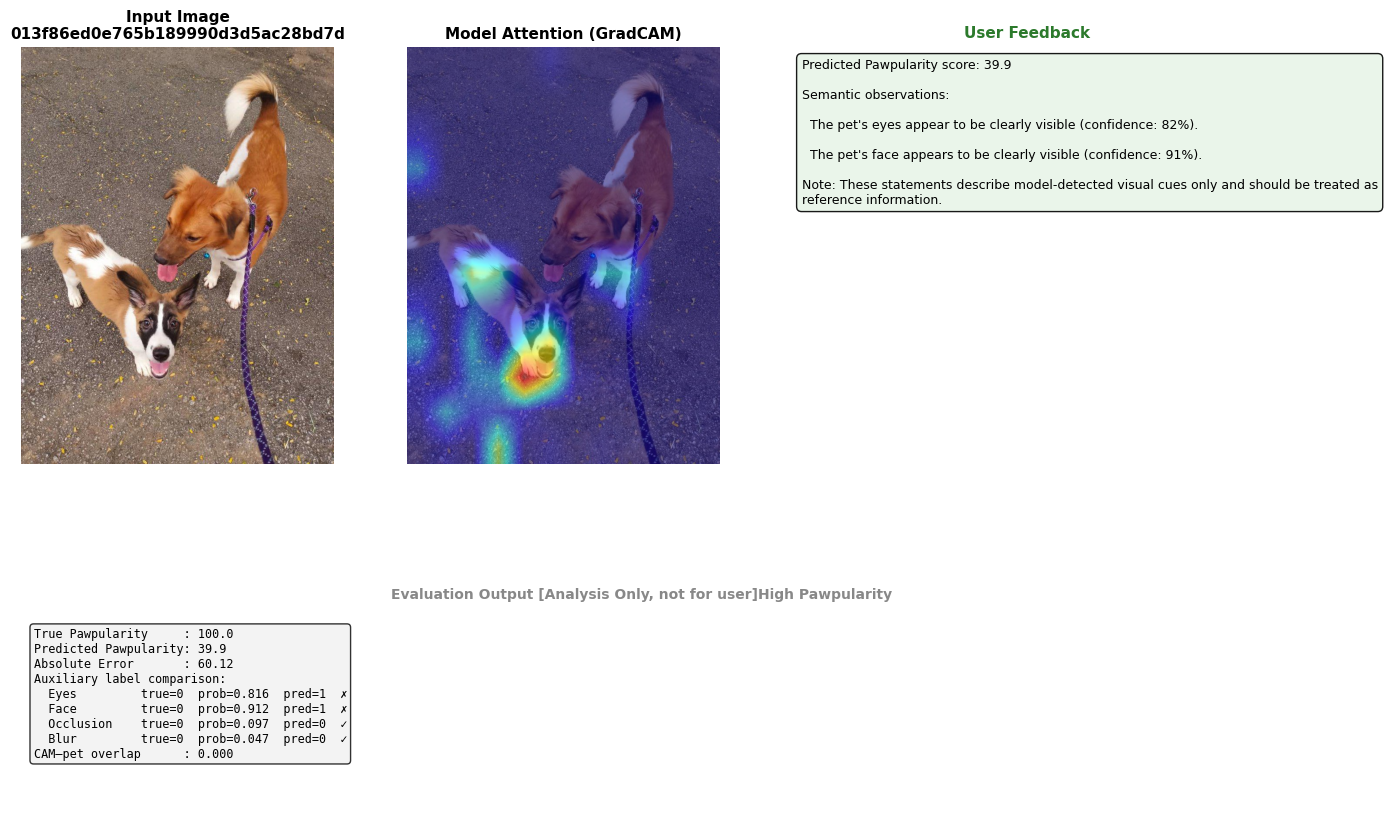

********************************************************************************

ImgId: e0a1e


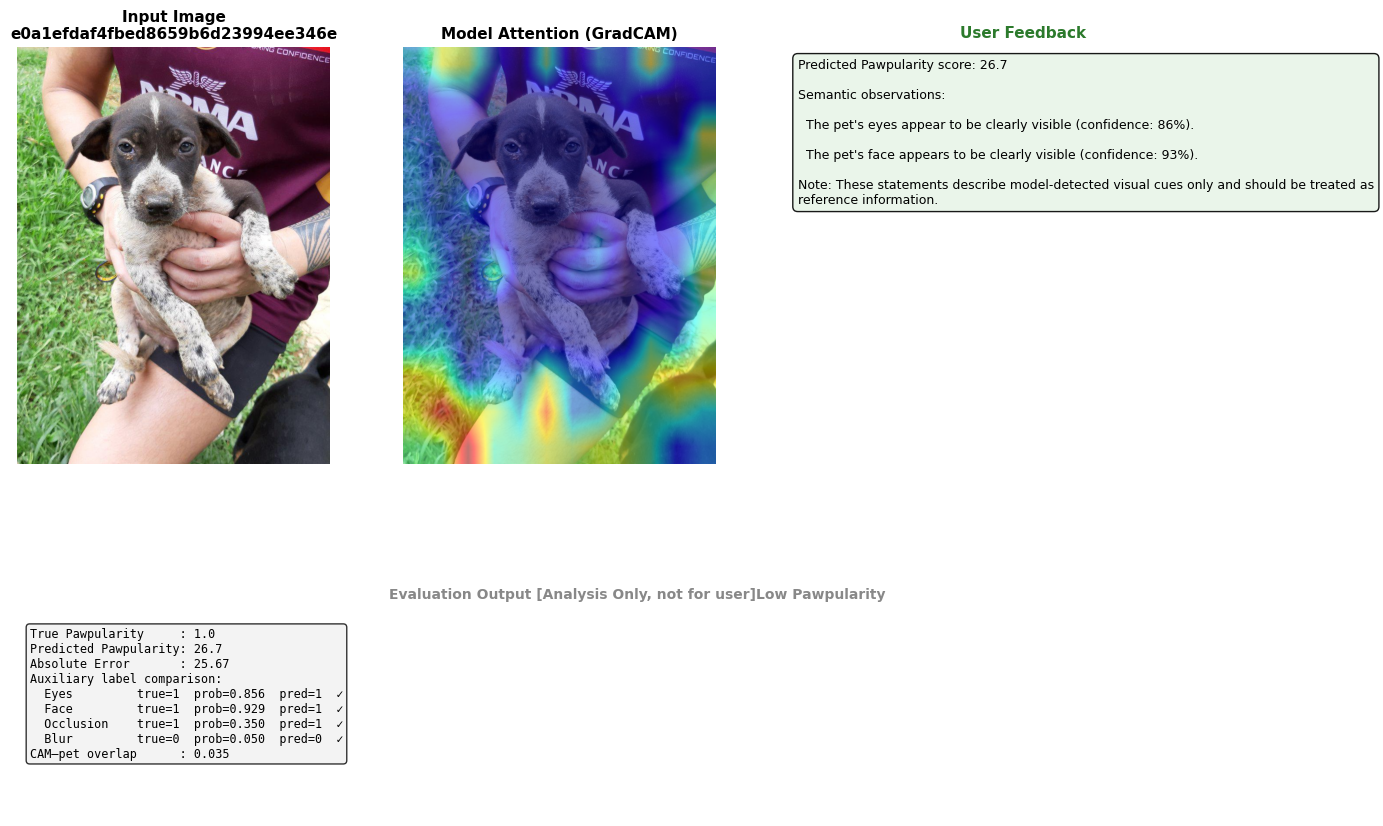

********************************************************************************

ImgId: 0f084


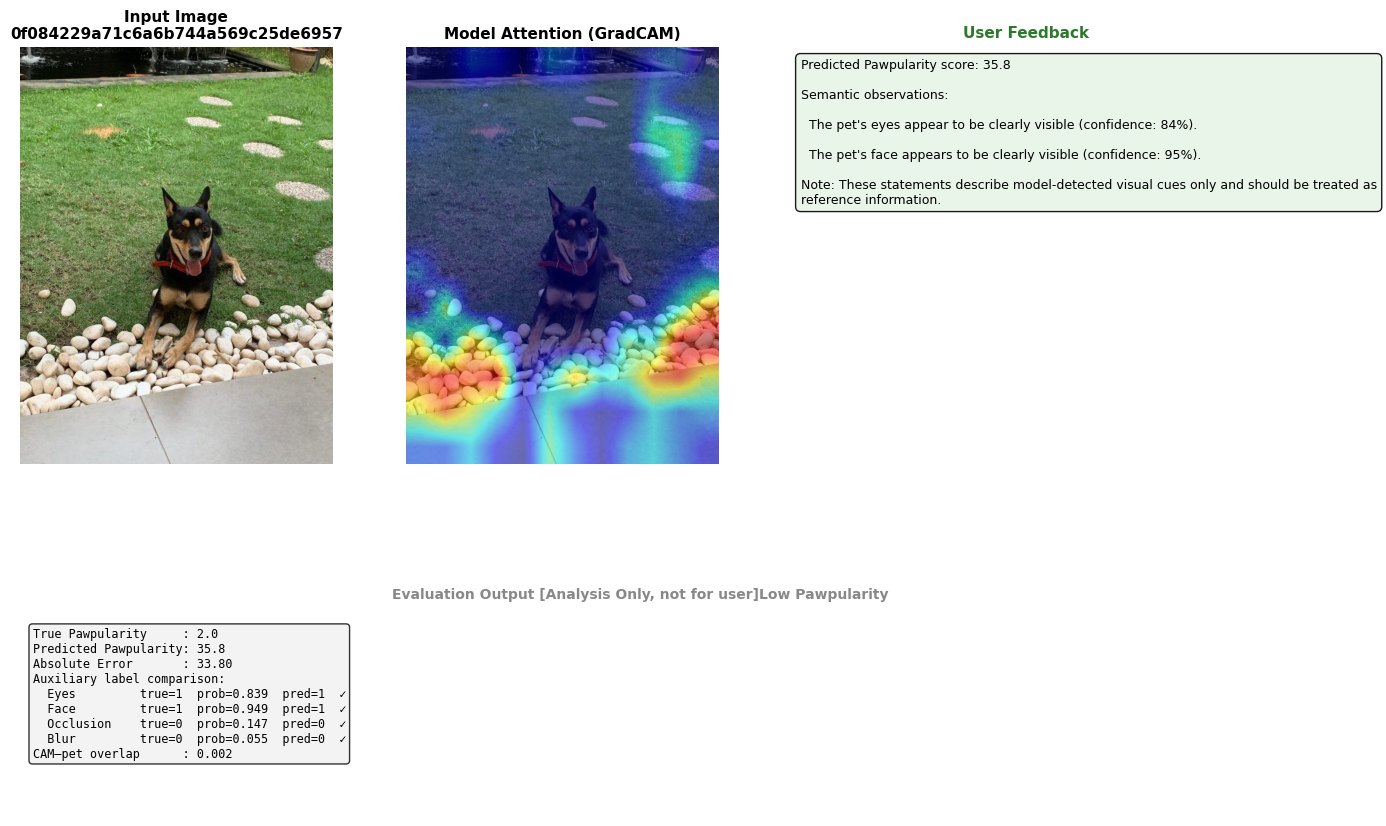

********************************************************************************

ImgId: 01677


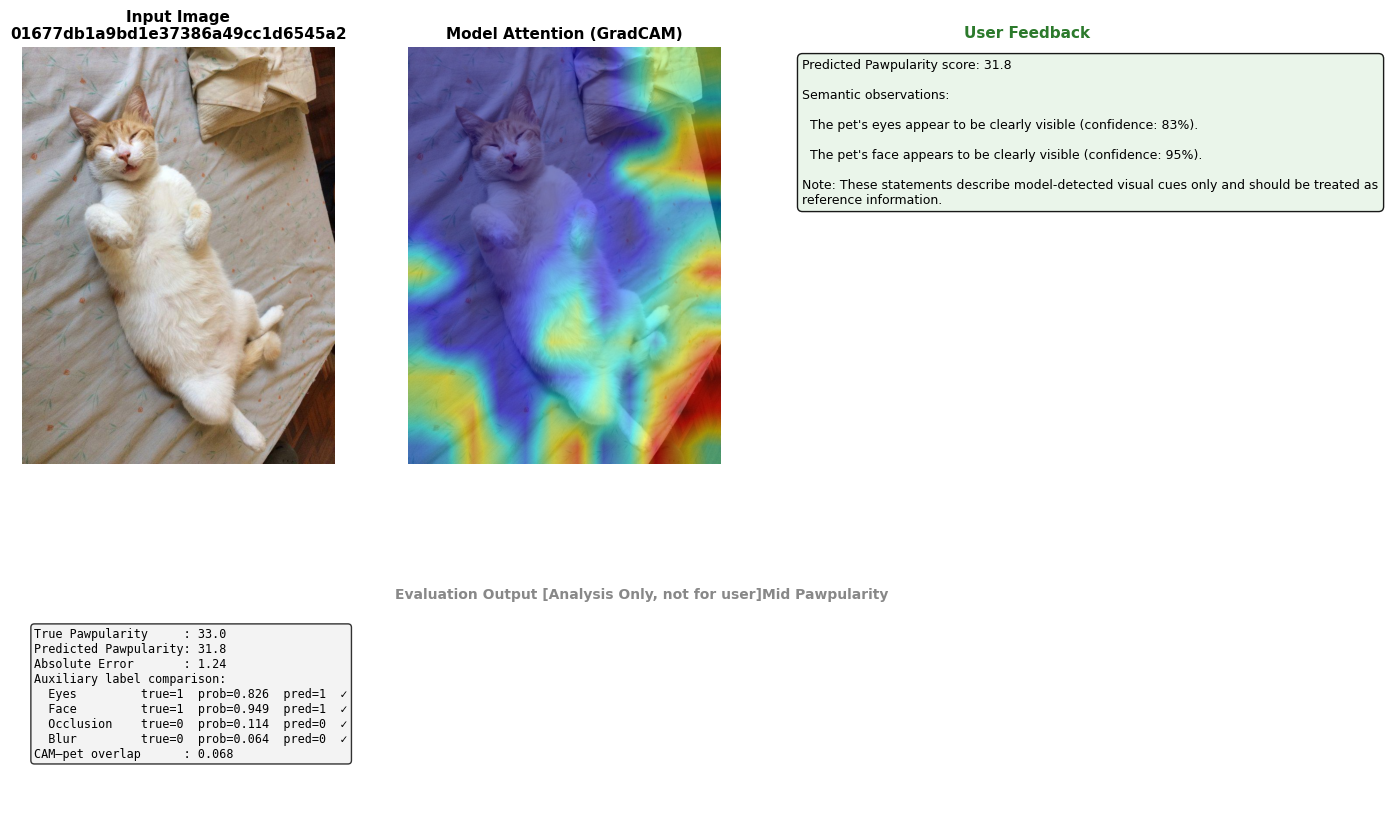

********************************************************************************

ImgId: 02eaa


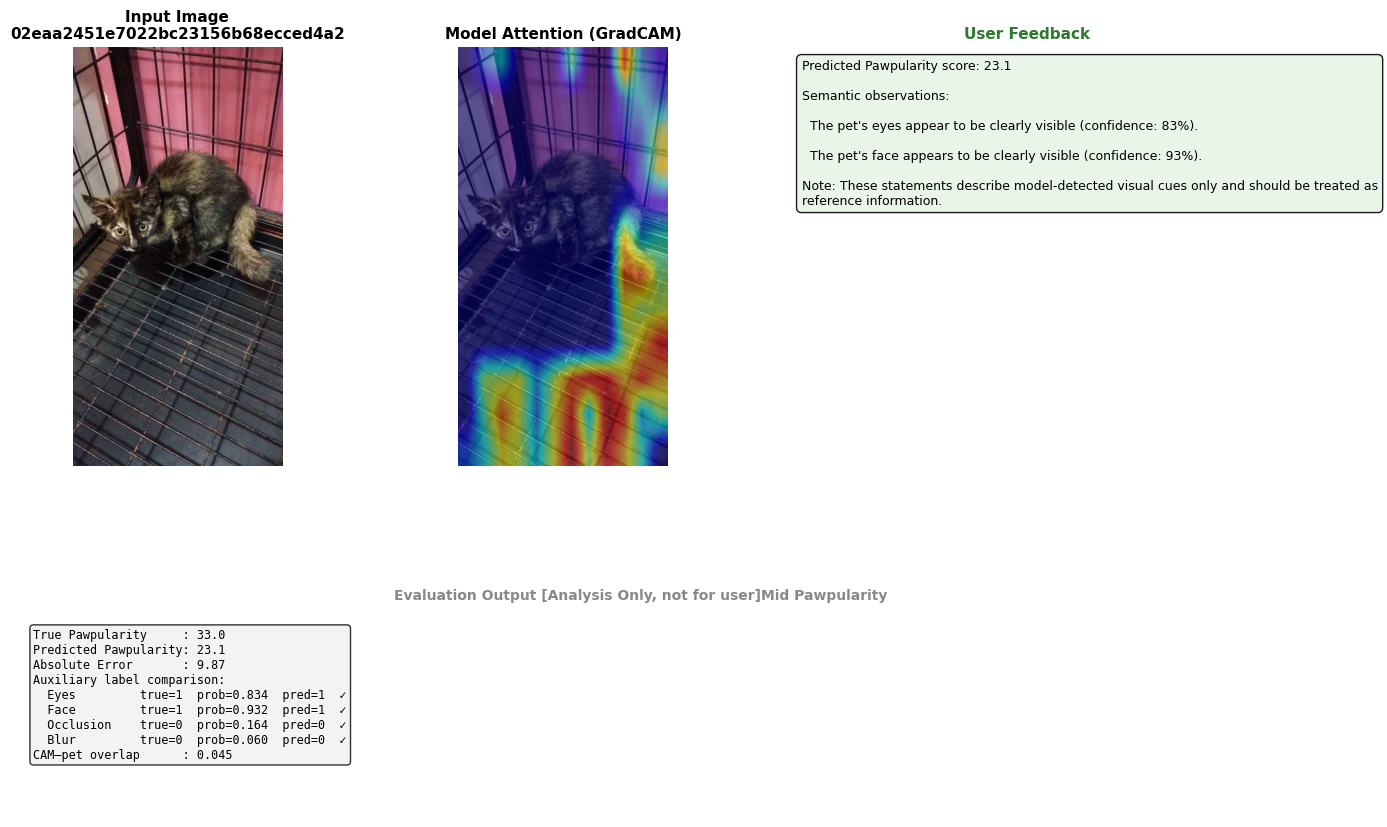

,Id,true_paw,pred_paw,cam_pet_overlap,eyes_true,eyes_prob,eyes_pred,face_true,face_prob,face_pred,occlusion_true,occlusion_prob,occlusion_pred,blur_true,blur_prob,blur_pred
0,00768659c1c90409f81dcdecbd270513,100,40.93,0.000,1,0.857,1,1,0.966,1,0,0.123,0,0,0.050,0
1,013f86ed0e765b189990d3d5ac28bd7d,100,39.88,0.000,0,0.816,1,0,0.912,1,0,0.097,0,0,0.047,0
2,e0a1efdaf4fbed8659b6d23994ee346e,1,26.67,0.035,1,0.856,1,1,0.929,1,1,0.350,1,0,0.050,0
3,0f084229a71c6a6b744a569c25de6957,2,35.80,0.002,1,0.839,1,1,0.949,1,0,0.147,0,0,0.055,0
4,01677db1a9bd1e37386a49cc1d6545a2,33,31.76,0.068,1,0.826,1,1,0.949,1,0,0.114,0,0,0.064,0
5,02eaa2451e7022bc23156b68ecced4a2,33,23.13,0.045,1,0.834,1,1,0.932,1,0,0.164,0,0,0.060,0


In [42]:
# Pipeline outputs 1–6 produced per image inside run_batch:
#   1 — input image
#   2 — predicted Pawpularity score
#   3 — auxiliary semantic predictions and probabilities
#   4 — confidence-aware feedback
#   5 — Grad-CAM overlay
#   6 — separate user-facing and evaluation outputs
SAVE_DIR = os.path.join(main_folder, "outputs", "extra", "feedback_prototype")

result_df = run_batch(
    image_ids=pool_ids,
    img_folder=IMG_FOLDER,
    cfg=ACTIVE_CFG,
    allFolds_models=allFolds_models,
    label_policy=LABEL_POLICY,
    aux_tasks=AUX_TASKS,
    swin_grid=SWIN_GRID,
    device=device,
    true_paw_dict=true_paw_dict,
    true_aux_dict=true_aux_dict,
    save_dir=SAVE_DIR,
    use_yolo=True,
    labels=labels
)
result_df

### 3) Success and Failure Images

Success (Face): ['00768659c1c90409f81dcdecbd270513']
Failure (Face): ['013f86ed0e765b189990d3d5ac28bd7d']
Failure (Eyes): ['013f86ed0e765b189990d3d5ac28bd7d']
Success (Occlusion): ['e0a1efdaf4fbed8659b6d23994ee346e']
Failure (Occlusion): []
********************************************************************************

ImgId: 00768


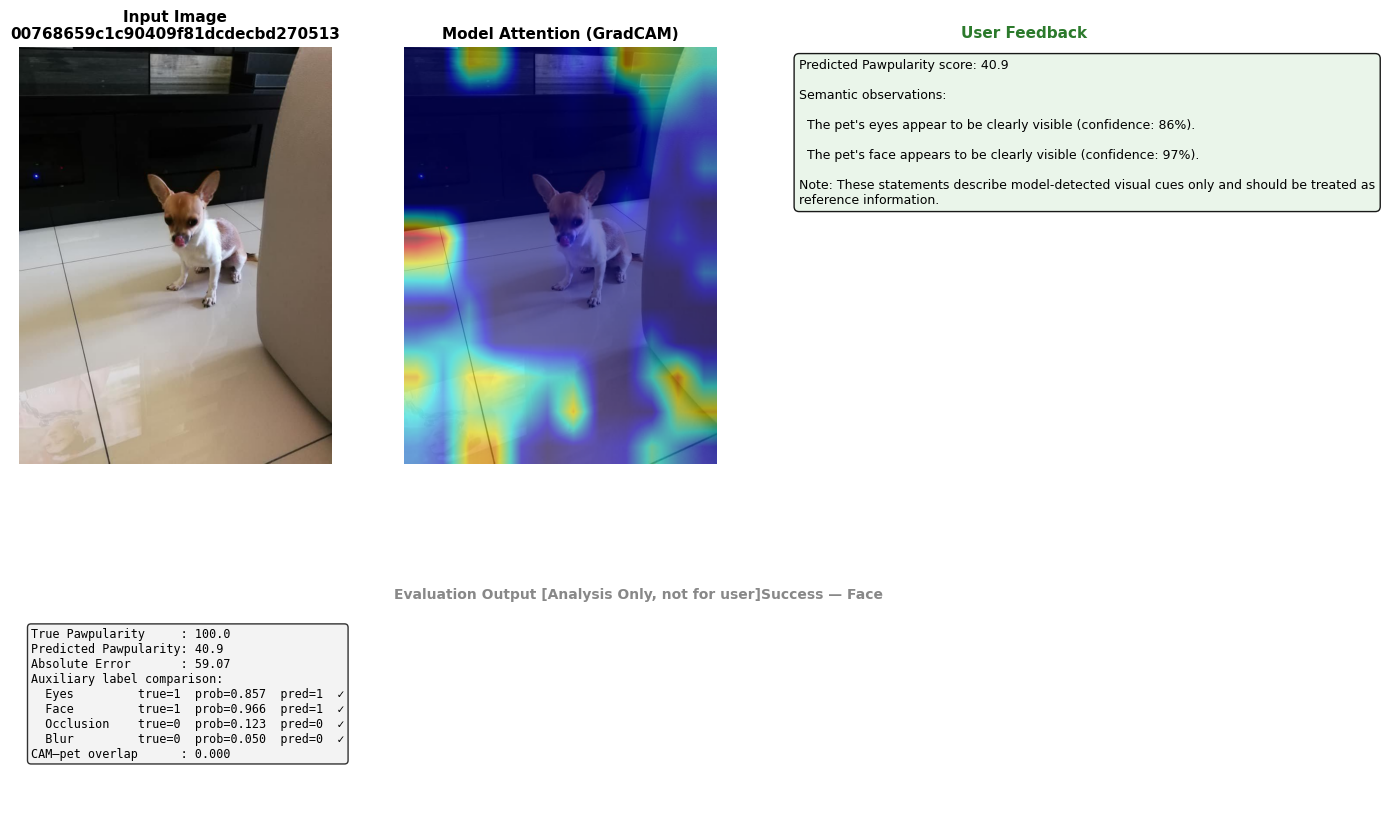

********************************************************************************

ImgId: 013f8


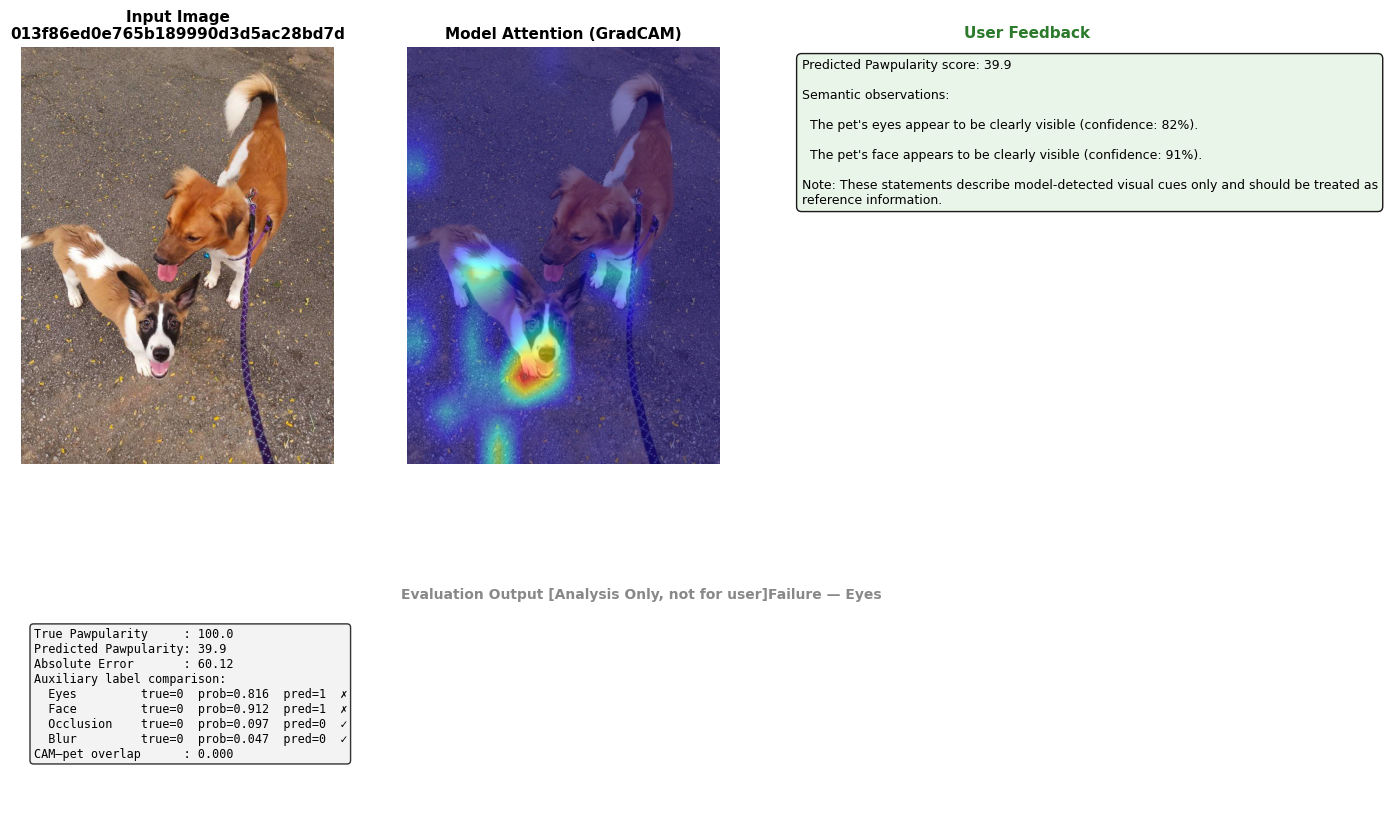

********************************************************************************

ImgId: 013f8


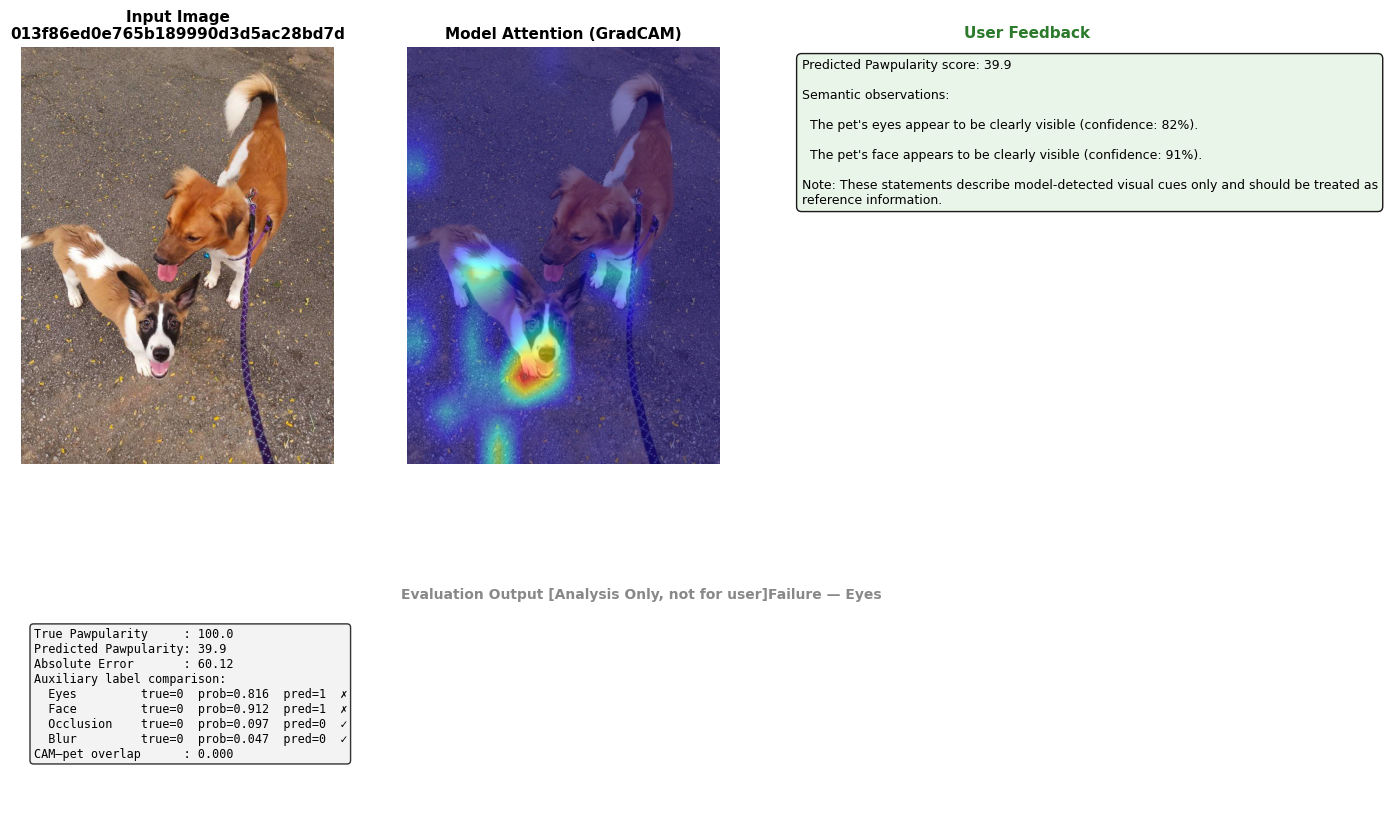

********************************************************************************

ImgId: e0a1e


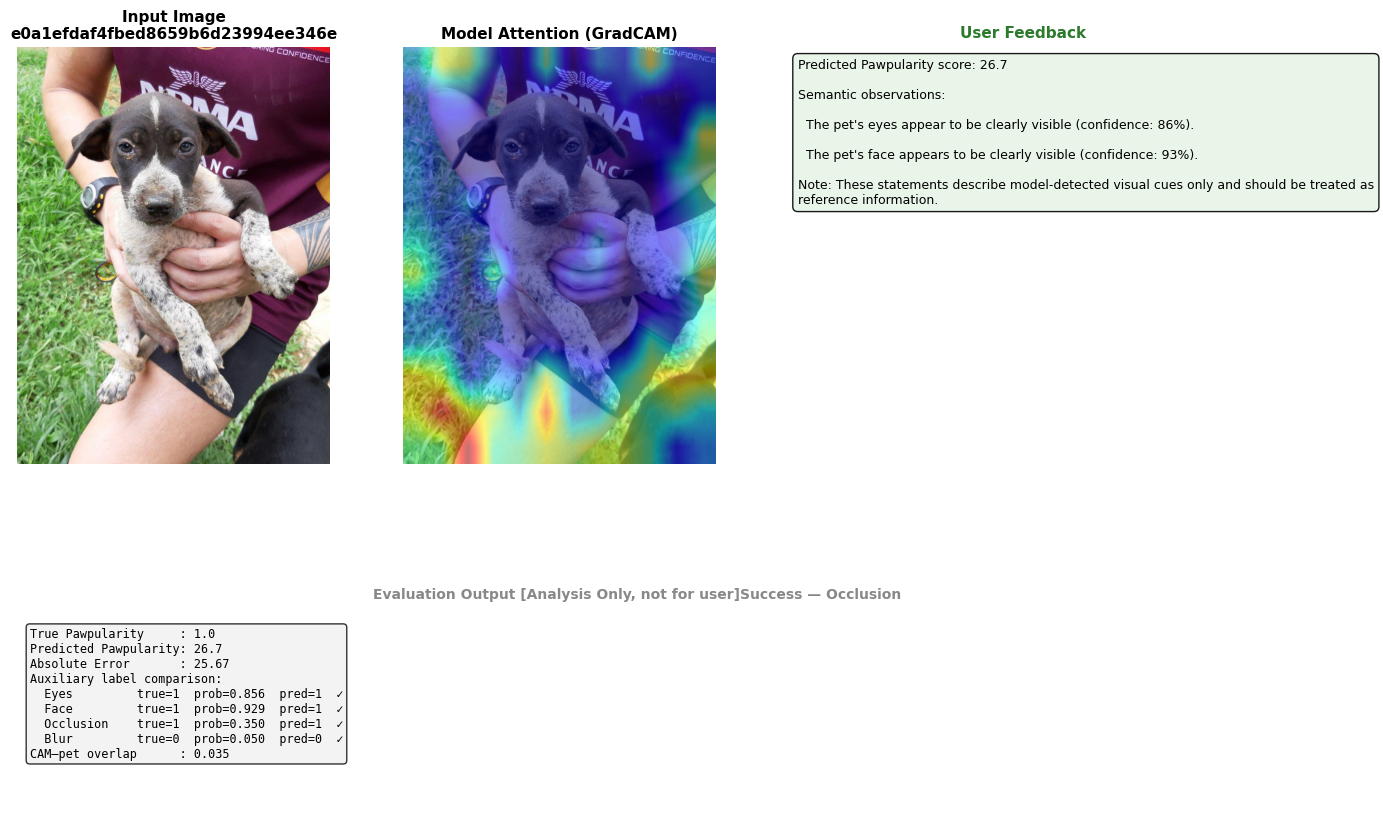

,Id,true_paw,pred_paw,cam_pet_overlap,eyes_true,eyes_prob,eyes_pred,face_true,face_prob,face_pred,occlusion_true,occlusion_prob,occlusion_pred,blur_true,blur_prob,blur_pred
0,00768659c1c90409f81dcdecbd270513,100,40.93,0.000,1,0.857,1,1,0.966,1,0,0.123,0,0,0.050,0
1,013f86ed0e765b189990d3d5ac28bd7d,100,39.88,0.000,0,0.816,1,0,0.912,1,0,0.097,0,0,0.047,0
2,013f86ed0e765b189990d3d5ac28bd7d,100,39.88,0.000,0,0.816,1,0,0.912,1,0,0.097,0,0,0.047,0
3,e0a1efdaf4fbed8659b6d23994ee346e,1,26.67,0.035,1,0.856,1,1,0.929,1,1,0.350,1,0,0.050,0


In [43]:

failure_face = result_df[
    (result_df["face_true"] == 0) & (result_df["face_pred"] == 1)
]["Id"].tolist()

# Success: high-confidence correct Face prediction (prob above uncertain zone)
success_face = result_df[
    (result_df["face_true"] == 1) &
    (result_df["face_prob"] > LABEL_POLICY["Face"]["uncertain_high"])
]["Id"].tolist()

# Failure (false positive) on Eyes
failure_eyes = result_df[
    (result_df["eyes_true"] == 0) & (result_df["eyes_pred"] == 1)
]["Id"].tolist()

# Success: high-confidence correct Occlusion prediction (prob above uncertain zone)
success_occlusion = result_df[
    (result_df["occlusion_true"] == 1) &
    (result_df["occlusion_prob"] > LABEL_POLICY["Occlusion"]["uncertain_high"])
]["Id"].tolist()

# Failure (false positive) on Occlusion
failure_occlusion = result_df[
    (result_df["occlusion_true"] == 0) & (result_df["occlusion_pred"] == 1)
]["Id"].tolist()

demo_ids = success_face[:1] + failure_face[:1] + failure_eyes[:1] + success_occlusion[:1] + failure_occlusion[:1]
print("Success (Face):",      success_face[:1])
print("Failure (Face):",      failure_face[:1])
print("Failure (Eyes):",      failure_eyes[:1])
print("Success (Occlusion):", success_occlusion[:1])
print("Failure (Occlusion):", failure_occlusion[:1])

# Meaningful label per image for readable print output
demo_labels = {}
for img_id in success_face[:1]:
    demo_labels[img_id] = "Success — Face"
for img_id in failure_face[:1]:
    demo_labels[img_id] = "Failure — Face"
for img_id in failure_eyes[:1]:
    demo_labels[img_id] = "Failure — Eyes"
for img_id in success_occlusion[:1]:
    demo_labels[img_id] = "Success — Occlusion"
for img_id in failure_occlusion[:1]:
    demo_labels[img_id] = "Failure — Occlusion"

SAVE_DIR_DEMO = os.path.join(main_folder, "outputs", "extra", "feedback_prototype_demo")
demo_df = run_batch(
    image_ids=demo_ids,
    img_folder=IMG_FOLDER,
    cfg=ACTIVE_CFG,
    allFolds_models=allFolds_models,
    label_policy=LABEL_POLICY,
    aux_tasks=AUX_TASKS,
    swin_grid=SWIN_GRID,
    device=device,
    true_paw_dict=true_paw_dict,
    true_aux_dict=true_aux_dict,
    save_dir=SAVE_DIR_DEMO,
    use_yolo=True,
    labels=demo_labels,
)
demo_df